# Lab 5 solution: TCP Calibration

Companion to `TCPCalibrationTemplate.ipynb` (`pdfs/TCP_Calibration.pdf`). **The code cells are the template's own cells with the blanks filled in**
(changes beyond the blanks are commented in the cell). After each code cell:
- **Concept**: what the task computes and why;
- **How it works**: the code line by line, every new piece of syntax with a tiny example;
- sometimes an **Example**: a short check, shown as code + its real output (text only, nothing extra to run).

**No robot cells.** The data are poses recorded earlier on the real robot; everything runs offline and all outputs
below are real.

**Run from `solutions/`.** `import labpaths` (added to the setup cell) puts the repo root on `sys.path`, so
`helperFunctions.py` imports as in the template, and finds the course URDF `mycobot_280_gazebo.urdf` in the repo root.

**The idea of the lab.** FK gives the pose of the **flange** (the robot's last link). The working point of the tool,
the **TCP** (tool center point: suction tip, pen tip), sits at a fixed offset ${}^F T_T$ from the flange. Each recorded
pose gives one estimate ${}^F T_T = ({}^B T_F)^{-1}\,{}^B T_{TCP}$; averaging several estimates, then checking how well the
average explains the data, is the calibration.

# TCP Calibration for the myCobot 280 Labs
## Lab 5: Flange-to-TCP Estimation, Validation, and Workflow Integration

Run this notebook from `~/venvs/mycobot`:

```bash
source ~/venvs/mycobot/bin/activate
jupyter lab
```

This lab continues Labs 1–4. You will work with real measurement data from the physical myCobot 280 to estimate the rigid geometric offset between the robot flange and the actual tool point (TCP). The estimated TCP is then validated and used in later Cartesian robot workflows.

All positions in this notebook are converted to **metres** and orientations to **radians** for computation. The raw measurement data is recorded in millimetres and degrees, matching the myCobot API convention.

In [1]:
%matplotlib widget
import os
import math
import numpy as np
import matplotlib.pyplot as plt
import roboticstoolbox as rtb

from spatialmath import SE3
import labpaths    # added: repo root on sys.path (helperFunctions.py) + URDF location
from helperFunctions import (
    rpy_to_rot, rpy_to_transform, rot_to_vec, transform_to_pipi,
)

np.set_printoptions(precision=6, suppress=True)    # suppress=True added: no 1e-17 noise in printed arrays

**How it works**
- `import math`: the standard-library math functions (`math.asin`, `math.atan2`) for single numbers (Task 16); NumPy's
  versions work on whole arrays.
- `precision=6`: offsets of fractions of a millimetre are printed in metres, so 6 decimals are needed.

## Setup

### 1. Import the myCobot 280 URDF model

Load the URDF model distributed alongside this notebook. The kinematic chain runs from `g_base` to `joint6_flange`. The flange frame is the last robot frame before any tool correction — the TCP frame is what we are calibrating.

In [2]:
notebook_path = os.getcwd()
mycobot_urdf_path = os.path.join(notebook_path, 'mycobot_280_gazebo.urdf')
if not os.path.exists(mycobot_urdf_path):        # added: the notebook runs in solutions/, the URDF is in the repo root
    mycobot_urdf_path = labpaths.urdf_path()
mycobot = rtb.Robot.URDF(mycobot_urdf_path)
print(mycobot)

for link in mycobot.links:
    print(link.name)

Using course URDF: /home/mano-ub22/TUD/cobots/mycobot_280_gazebo.urdf
ERobot: mycobot_280_gazebo, 6 joints (RRRRRR), dynamics, geometry, collision
┌──────┬────────────────┬───────┬────────┬─────────────────────────────────────────────────────┐
│ link │      link      │ joint │ parent │                 ETS: parent to link                 │
├──────┼────────────────┼───────┼────────┼─────────────────────────────────────────────────────┤
│    0 │ world          │       │ BASE   │ SE3()                                               │
│    1 │ g_base         │       │ world  │ SE3()                                               │
│    2 │ joint1         │       │ g_base │ SE3()                                               │
│    3 │ joint2         │     0 │ joint1 │ SE3(0, 0, 0.1396) ⊕ Rz(q0)                          │
│    4 │ joint3         │     1 │ joint2 │ SE3(0, 0, -0.001; 180°, 90°, 90°) ⊕ Rz(q1)          │
│    5 │ joint4         │     2 │ joint3 │ SE3(-0.1104, 0, 0) ⊕ Rz(q2)       

/tmp/ipykernel_64719/3780298154.py:5: DeprecationWarning: Robot.URDF() is deprecated. Subclass roboticstoolbox.models.URDF.URDFRobot, or call URDF_read() from that module and construct Robot directly.
  mycobot = rtb.Robot.URDF(mycobot_urdf_path)


**How it works** (as in Labs 3–4): `Robot.URDF(path)` builds the kinematic tree; the chain used here runs from `g_base`
to `joint6_flange`.

### 2. Identify the relevant frames

The two frames central to this lab are:

- **Base frame:** `g_base` — the fixed robot base used by the URDF and the controller.
- **Flange frame:** `joint6_flange` — the last link in the kinematic chain before any tool is attached.

The **TCP frame** is rigidly attached to the mounted tool. Its offset from the flange is the unknown we will estimate. After calibration, the offset is applied through the launch parameters `ik_tool_xyz` and `ik_tool_rpy` so that IK and Cartesian commands refer to the calibrated TCP rather than the raw flange.

In [3]:
base_link = 'g_base'
flange_link = 'joint6_flange'

# Verify FK at home configuration
q_home = np.zeros(mycobot.n)
T_home = mycobot.fkine(q_home, end=flange_link)
print('Flange pose at home:\n', T_home)

Flange pose at home:
    0        -3.673e-06  1         0.0456    
  -1         3.673e-06  1.349e-11 -0.06362   
  -3.673e-06 -1        -3.673e-06  0.4181    
   0         0         0         1         



**Concept.** Three frames: **base** `g_base` (fixed to the table), **flange** `joint6_flange` (end of the robot, known
from FK), **TCP** (on the tool, unknown, the thing to calibrate).

**How it works**
- `np.zeros(mycobot.n)`: the all-zero joint vector (arm straight up); `fkine(q, end=...)` gives the flange pose there:
  about 0.42 m above the base.

## Measurement Data and Sample Structure

### 3. Load the calibration samples

Each calibration sample consists of three measurements recorded on the physical myCobot 280:

- **Joint angles** in degrees (read from the robot encoders)
- **Measured TCP position** in millimetres (from the myCobot API `get_coords`)
- **Measured TCP orientation** as roll-pitch-yaw in degrees (from the same API)

The samples below are the actual measurements used in the codebase calibration script `fk_tool_calib.py`. Each row represents one robot pose where the tool point was recorded.

In [4]:
# Actual calibration samples from fk_tool_calib.py
# Format: (joint_angles_deg, tcp_xyz_mm, tcp_rpy_deg)
samples = [
    ([-0.87, -2.02, -89.91, 89.38, 1.05, 0.7],
     [147.7, -64.8, 319.4],
     [-92.54, 0.74, -89.85]),

    ([-0.52, -0.87, -0.61, -0.08, 0.96, 0.61],
     [51.1, -63.1, 419.5],
     [-91.58, 0.64, -89.66]),

    ([9.49, 20.56, 29.61, 40.86, 49.3, 59.41],
     [-180.7, -59.4, 332.6],
     [-44.61, -23.67, -11.74]),

    ([59.23, 51.15, 39.9, 31.02, 20.83, 10.63],
     [-96.6, -254.5, 203.1],
     [30.49, -23.21, -32.58]),

    ([-59.15, -50.71, -40.34, 39.28, 49.3, 59.41],
     [107.9, -236.9, 230.6],
     [158.88, 56.69, 158.02]),
]

print(f'Number of calibration samples: {len(samples)}')

Number of calibration samples: 5


**Concept.** Five poses recorded on the real arm: joint angles from the encoders, TCP position and RPY from the robot's
API `get_coords`, i.e. from the robot's **own internal kinematics**. So the offset estimated here mostly absorbs the
difference between that internal model and the URDF (a couple of millimetres), not a real tool. With a suction nozzle
mounted the same procedure gives centimetres (Lab 8: 68 mm).

**How it works**
- `samples` is a **list of tuples**; each tuple holds three lists. `samples[0]` = first tuple, `samples[0][1]` = its
  position, `samples[0][1][2]` = its z (319.4).
- The poses differ strongly in position and orientation (sample 5: roll 159°): that is what makes a calibration
  well-conditioned (Task 18).

### 4. Convert one sample to SI units

Convert the first sample from the raw measurement units to the computation units used in this notebook:
- Joint angles: degrees → radians
- TCP position: millimetres → metres
- TCP orientation: degrees → radians

In [5]:
angles_deg, tcp_xyz_mm, tcp_rpy_deg = samples[0]

q_rad = np.radians(angles_deg)  # Convert the encoder joint angles to radians
tcp_xyz_m = np.array(tcp_xyz_mm) / 1000.0  # Convert the measured TCP position to metres
tcp_rpy_rad = np.radians(tcp_rpy_deg)  # Convert the measured TCP orientation to radians

print('q (rad):', q_rad)
print('TCP xyz (m):', tcp_xyz_m)
print('TCP rpy (rad):', tcp_rpy_rad)

q (rad): [-0.015184 -0.035256 -1.569226  1.559975  0.018326  0.012217]
TCP xyz (m): [ 0.1477 -0.0648  0.3194]
TCP rpy (rad): [-1.615128  0.012915 -1.568178]


**How it works**
- `a, b, c = samples[0]`: **tuple unpacking**, the three parts get three names.
- `np.radians(list)` converts a whole list and returns an array.
- `np.array(tcp_xyz_mm) / 1000.0`: a plain list cannot be divided (`[1, 2] / 1000` is a `TypeError`); a NumPy array is
  divided **element-wise**.

## Per-Sample Flange-to-TCP Transform

### 5. Compute the flange-to-TCP transform for one sample

For each measurement sample, the flange-to-TCP transform is obtained by:

1. Computing the flange pose ${}^B\mathbf{T}_{F,i}$ from FK using the recorded joint angles.
2. Assembling the measured TCP pose ${}^B\mathbf{T}_{\text{TCP},i}$ from the recorded position and RPY orientation using the codebase RPY convention (`rpy_to_transform`).
3. Computing the per-sample offset: ${}^F\mathbf{T}_{T,i} = \left({}^B\mathbf{T}_{F,i}\right)^{-1} {}^B\mathbf{T}_{\text{TCP},i}$

In [6]:
# Step 1: FK to get flange pose in base frame
T_base_flange = mycobot.fkine(q_rad, end=flange_link).A  # flange pose in the base frame (4x4 array)

# Step 2: Assemble measured TCP pose using codebase RPY convention
T_base_tcp = rpy_to_transform(tcp_xyz_m, tcp_rpy_rad)  # measured TCP pose from position and orientation

# Step 3: Per-sample flange-to-TCP transform
T_flange_tcp = np.linalg.inv(T_base_flange) @ T_base_tcp  # relative transform from flange to TCP

print('Flange pose (base frame):\n', T_base_flange)
print('Measured TCP pose (base frame):\n', T_base_tcp)
print('Flange-to-TCP transform:\n', T_flange_tcp)
print('TCP offset (mm):', T_flange_tcp[:3, 3] * 1000.0)

Flange pose (base frame):
 [[ 0.00258  -0.044525  0.999005  0.14767 ]
 [-0.999912  0.012896  0.003157 -0.065035]
 [-0.013024 -0.998925 -0.044487  0.316737]
 [ 0.        0.        0.        1.      ]]
Measured TCP pose (base frame):
 [[ 0.002618 -0.04435   0.999013  0.1477  ]
 [-0.999913  0.012786  0.003188 -0.0648  ]
 [-0.012915 -0.998934 -0.044313  0.3194  ]
 [ 0.        0.        0.        1.      ]]
Flange-to-TCP transform:
 [[ 1.        0.00011  -0.000033 -0.00027 ]
 [-0.00011   1.       -0.000174 -0.002658]
 [ 0.000033  0.000174  1.       -0.000087]
 [ 0.        0.        0.        1.      ]]
TCP offset (mm): [-0.269679 -2.658363 -0.087355]


**Concept.** Going base → flange → TCP: ${}^BT_{TCP} = {}^BT_F\,{}^FT_T$. Multiply from the left by $({}^BT_F)^{-1}$ and
the unknown is alone: ${}^FT_T = ({}^BT_F)^{-1}\,{}^BT_{TCP}$, "the TCP seen from the flange".

**How it works**
- Step 1: `fkine(...).A` = flange pose as a 4×4 array.
- Step 2: `rpy_to_transform(xyz, rpy)` builds a pose with $R = R_z(yaw)R_y(pitch)R_x(roll)$, the controller's convention.
- Step 3: `np.linalg.inv(T)` = matrix inverse; for a transform it equals $\begin{bmatrix}R^T & -R^Tt\\0&1\end{bmatrix}$ (Lab 1).
  `@` multiplies matrices; the order matters (`A @ B` ≠ `B @ A`).
- Result: an offset of a few millimetres and a rotation close to the identity.

**Example: going forward again gives the measurement back**

```python
print(np.allclose(T_base_flange @ T_flange_tcp, T_base_tcp))
angle = np.degrees(np.arccos(np.clip((np.trace(T_flange_tcp[:3, :3]) - 1) / 2, -1, 1)))
print(f'rotation between flange and TCP frame: {angle:.3f} deg')
```

Output:
```text
True
rotation between flange and TCP frame: 0.012 deg
```

Rotation angle from the trace (Lab 2): $\cos\vartheta = (\mathrm{tr}\,R - 1)/2$. `np.clip(x, -1, 1)` keeps `arccos` safe from
rounding values like 1.0000000002.

### 6. Compute flange-to-TCP transforms for all samples

Repeat the per-sample computation over all calibration samples. Store the resulting transforms, translation vectors, and rotation matrices separately.

In [7]:
flange_to_tcp_transforms = []
flange_to_tcp_translations = []
flange_to_tcp_rotations = []

for angles_deg, tcp_xyz_mm, tcp_rpy_deg in samples:
    q_rad = np.radians(angles_deg)  # convert to radians
    tcp_xyz_m = np.array(tcp_xyz_mm) / 1000.0  # convert to metres
    tcp_rpy_rad = np.radians(tcp_rpy_deg)  # convert to radians

    T_base_flange = mycobot.fkine(q_rad, end=flange_link).A  # flange pose in the base frame
    T_base_tcp = rpy_to_transform(tcp_xyz_m, tcp_rpy_rad)  # measured TCP pose
    T_flange_tcp = np.linalg.inv(T_base_flange) @ T_base_tcp  # relative transform flange -> TCP

    flange_to_tcp_transforms.append(T_flange_tcp)
    flange_to_tcp_translations.append(T_flange_tcp[:3, 3])
    flange_to_tcp_rotations.append(T_flange_tcp[:3, :3])

print(f'Computed {len(flange_to_tcp_transforms)} per-sample transforms.')
for i, t in enumerate(flange_to_tcp_translations):
    print(f'  Sample {i+1} offset (mm): {t * 1000.0}')

Computed 5 per-sample transforms.
  Sample 1 offset (mm): [-0.269679 -2.658363 -0.087355]
  Sample 2 offset (mm): [-0.253934 -2.668324 -0.123191]
  Sample 3 offset (mm): [-1.333631 -1.299867  0.714932]
  Sample 4 offset (mm): [-0.228784 -1.356111  0.642653]
  Sample 5 offset (mm): [-2.3188   -0.620976 -0.287042]


**Concept.** One estimate per pose. If the TCP were a perfect rigid point and the data noise-free, all five would be
equal; their **spread** (here about 2 mm in y) is measurement noise plus the difference between the two kinematic models.

**How it works**
- `for a, b, c in samples:` unpacks each tuple in the loop header.
- Empty lists + `.append(x)` collect one result per sample; `T[:3, 3]` = translation, `T[:3, :3]` = rotation block.
- `enumerate(list)` yields `(index, item)`; `i+1` makes the sample numbers start at 1.

## Estimate a Common TCP Transform

### 7. Average the translational offset

Average the per-sample TCP translation vectors component-wise to obtain a single estimated translation offset.

In [8]:
mean_translation = np.mean(flange_to_tcp_translations, axis=0)  # component-wise average over the samples

print('Mean TCP offset (m):', mean_translation)
print('Mean TCP offset (mm):', mean_translation * 1000.0)

Mean TCP offset (m): [-0.000881 -0.001721  0.000172]
Mean TCP offset (mm): [-0.880965 -1.720728  0.172   ]


**Concept.** The mean is the least-squares answer to "one offset that best explains all samples" (it minimises
$\sum_i\lVert t_i - t\rVert^2$). Translations can be averaged component-wise; rotations cannot (Task 8).

**How it works**
- `np.mean(list_of_vectors, axis=0)`: NumPy stacks the list into a 5×3 array and averages **down the rows** (one mean per
  column x, y, z). Example: `np.mean([[1, 2, 3], [3, 4, 5]], axis=0)` → `[2, 3, 4]`; `axis=1` would give `[2, 4]`.

### 8. SVD-based mean rotation

Average the per-sample rotation matrices using an SVD projection. Simply averaging rotation matrices element-wise does not produce a valid rotation. The SVD-based approach:

1. Sum all rotation matrices.
2. Compute the SVD of the sum.
3. Project back to SO(3): $\bar{\mathbf{R}} = \mathbf{U}\mathbf{V}^T$.
4. Check the determinant: if $\det(\bar{\mathbf{R}}) < 0$, negate the last column of $\mathbf{U}$ and recompute.

This matches the `mean_rotation` function in the codebase's `fk_tool_calib.py`.

In [9]:
def mean_rotation_svd(rotations):
    """SVD-based mean rotation (matches fk_tool_calib.py)."""
    R_sum = np.sum(rotations, axis=0)  # sum all rotation matrices
    U, _, Vt = np.linalg.svd(R_sum)
    R_mean = U @ Vt  # the rotation matrix closest to R_sum
    # Ensure proper rotation (det > 0)
    if np.linalg.det(R_mean) < 0:
        U[:, -1] *= -1          # flip the last column of U ...
        R_mean = U @ Vt         # ... and recompute
    return R_mean

R_mean = mean_rotation_svd(flange_to_tcp_rotations)
print('Mean rotation:\n', R_mean)
print('det(R_mean):', np.linalg.det(R_mean))

Mean rotation:
 [[ 1.       -0.000054  0.000252]
 [ 0.000054  1.       -0.000049]
 [-0.000252  0.000049  1.      ]]
det(R_mean): 1.0000000000000013


**Concept.** The element-wise mean of rotation matrices is not a rotation (not orthogonal). The fix: sum them,
decompose $R_{sum} = U\Sigma V^T$, keep $\bar R = UV^T$, the **rotation closest to $R_{sum}$** (same step as the
Kabsch/Procrustes algorithm): keep the "direction", drop the stretching $\Sigma$. If $\det = -1$ (a reflection), flipping
the last column of $U$ makes it a proper rotation.

**How it works**
- `np.sum(list_of_3x3, axis=0)` adds the matrices; `np.linalg.svd` returns `U`, the singular values (`_`, unused) and
  `Vt` $= V^T$.
- `U[:, -1] *= -1`: `[:, -1]` = last column, `*=` multiplies in place.
- The triple-quoted string under `def` is the function's **docstring** (`help(mean_rotation_svd)` prints it).

**Example: why the naive average fails**

```python
from spatialmath.base import rotz
Ra, Rb = rotz(0.0), rotz(np.pi / 2)                   # 0 deg and 90 deg about z
R_naive = (Ra + Rb) / 2
print('naive mean is a rotation:', np.allclose(R_naive.T @ R_naive, np.eye(3)), '  det =', round(np.linalg.det(R_naive), 3))
R_svd = mean_rotation_svd([Ra, Rb])
print('SVD mean: rotation about z by', round(np.degrees(np.arctan2(R_svd[1, 0], R_svd[0, 0])), 3), 'deg')
```

Output:
```text
naive mean is a rotation: False   det = 0.5
SVD mean: rotation about z by 45.0 deg
```

The naive mean has det = 0.5 and $R^TR \ne I$; the SVD mean is the proper rotation halfway between (45°).

### 9. Assemble the estimated flange-to-TCP transform

Combine the averaged translation and the SVD-mean rotation into a single 4×4 homogeneous transform. This is the calibrated flange-to-TCP offset.

In [10]:
T_flange_tcp_est = np.eye(4)
T_flange_tcp_est[:3, :3] = R_mean  # Insert the estimated mean rotation
T_flange_tcp_est[:3, 3] = mean_translation  # Insert the estimated mean translation

print('Estimated flange-to-TCP transform:\n', T_flange_tcp_est)
print('Estimated TCP offset (mm):', T_flange_tcp_est[:3, 3] * 1000.0)

Estimated flange-to-TCP transform:
 [[ 1.       -0.000054  0.000252 -0.000881]
 [ 0.000054  1.       -0.000049 -0.001721]
 [-0.000252  0.000049  1.        0.000172]
 [ 0.        0.        0.        1.      ]]
Estimated TCP offset (mm): [-0.880965 -1.720728  0.172   ]


**How it works:** start from the 4×4 identity, write the rotation into the upper-left 3×3 block and the translation into
the first three rows of the last column (Lab 1). This is ${}^F\hat T_T$, the calibrated tool transform.

## Validate the Calibration

### 10. Reprojection: reconstruct TCP positions from the estimated offset

For each sample, reconstruct the TCP position using the estimated flange-to-TCP transform:

$${}^B\mathbf{T}_{\text{TCP,est},i} = {}^B\mathbf{T}_{F,i} \cdot {}^F\hat{\mathbf{T}}_T$$

Compare the reconstructed TCP position with the originally measured TCP position.

In [11]:
reconstructed_positions = []
measured_positions = []

for i, (angles_deg, tcp_xyz_mm, tcp_rpy_deg) in enumerate(samples):
    q_rad = np.radians(angles_deg)
    tcp_xyz_m = np.array(tcp_xyz_mm) / 1000.0

    T_base_flange = mycobot.fkine(q_rad, end=flange_link).A  # flange pose in the base frame
    T_base_tcp_est = T_base_flange @ T_flange_tcp_est  # TCP pose predicted with the calibration

    reconstructed_positions.append(T_base_tcp_est[:3, 3])
    measured_positions.append(tcp_xyz_m)

reconstructed_positions = np.array(reconstructed_positions)
measured_positions = np.array(measured_positions)

for i in range(len(samples)):
    print(f'Sample {i+1}: measured={measured_positions[i]*1000} mm, '
          f'reconstructed={reconstructed_positions[i]*1000} mm')

Sample 1: measured=[147.7 -64.8 319.4] mm, reconstructed=[147.915771 -64.175856 318.459796] mm
Sample 2: measured=[ 51.1 -63.1 419.5] mm, reconstructed=[ 51.364568 -62.460431 418.551739] mm
Sample 3: measured=[-180.7  -59.4  332.6] mm, reconstructed=[-180.397044  -60.158512  332.6984  ] mm
Sample 4: measured=[ -96.6 -254.5  203.1] mm, reconstructed=[ -96.949549 -254.366052  202.300203] mm
Sample 5: measured=[ 107.9 -236.9  230.6] mm, reconstructed=[ 107.484784 -237.660525  228.945691] mm


**Concept.** Use the calibration **forwards**: flange pose × estimated offset = predicted TCP. A good calibration
predicts the measurements closely.

**How it works**
- `for i, (a, b, c) in enumerate(samples):` unpacks the index and the sample tuple in one header.
- `np.array(list_of_vectors)` turns the lists into 5×3 arrays for Task 11.

### 11. Compute residual error measures

Compute the residual (difference between reconstructed and measured TCP positions) for each sample. Report the per-sample error norm, the mean residual norm, the maximum residual, and the RMS position error.

In [12]:
residuals = reconstructed_positions - measured_positions  # 5 x 3 position residuals
residual_norms = np.linalg.norm(residuals, axis=1)  # one residual length per sample
mean_residual = np.mean(residual_norms)
max_residual = np.max(residual_norms)
rms_error = np.sqrt(np.mean(residual_norms**2))  # root-mean-square position error

print('Per-sample residual norms (mm):')
for i, rn in enumerate(residual_norms):
    print(f'  Sample {i+1}: {rn * 1000.0:.4f} mm')
print(f'Mean residual: {mean_residual * 1000.0:.4f} mm')
print(f'Max residual:  {max_residual * 1000.0:.4f} mm')
print(f'RMS error:     {rms_error * 1000.0:.4f} mm')

Per-sample residual norms (mm):
  Sample 1: 1.1490 mm
  Sample 2: 1.1740 mm
  Sample 3: 0.8227 mm
  Sample 4: 0.8831 mm
  Sample 5: 1.8675 mm
Mean residual: 1.1792 mm
Max residual:  1.8675 mm
RMS error:     1.2363 mm


**Concept.** Mean = typical error; max = worst case (sensitive to one bad sample); RMS $= \sqrt{\tfrac1n\sum r_i^2}$
weighs large errors more (always ≥ the mean).

**How it works**
- `np.linalg.norm(residuals, axis=1)`: the length of each **row** $\sqrt{x^2+y^2+z^2}$, one per sample.
- `residual_norms**2` squares element-wise; `{x:.4f}` prints 4 decimals.

**Example: how much does the calibration help?**

```python
res_no_tool = np.linalg.norm(np.array([mycobot.fkine(np.radians(a), end=flange_link).A[:3, 3] for a, _, _ in samples])
                             - measured_positions, axis=1)
print('without calibration (mm):', np.round(res_no_tool * 1000, 2), ' mean %.2f' % (res_no_tool.mean() * 1000))
print('with calibration    (mm):', np.round(residual_norms * 1000, 2), ' mean %.2f' % (residual_norms.mean() * 1000))
```

Output:
```text
without calibration (mm): [2.67 2.68 1.99 1.52 2.42]  mean 2.26
with calibration    (mm): [1.15 1.17 0.82 0.88 1.87]  mean 1.18
```

`for a, _, _ in samples` keeps only the angles; `'%.2f' % x` is the older %-formatting (same as `f'{x:.2f}'`).

### 12. Plot residual norms

Visualise the residual norm for each measurement sample. A consistent calibration should show small, evenly distributed residuals. One unusually large residual may indicate a measurement outlier.

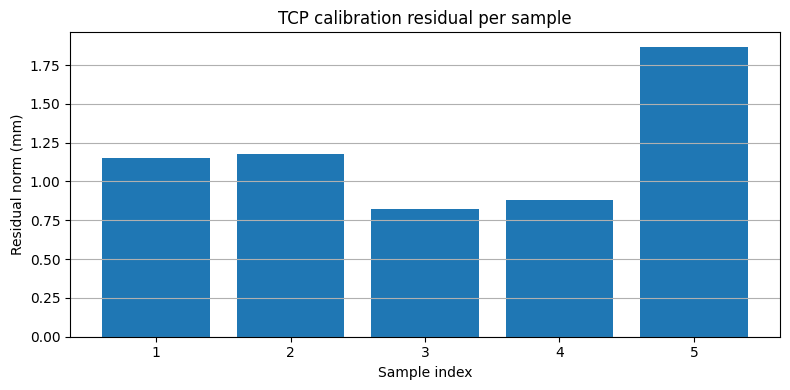

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, len(samples) + 1), residual_norms * 1000.0)
ax.set_xlabel('Sample index')
ax.set_ylabel('Residual norm (mm)')
ax.set_title('TCP calibration residual per sample')
ax.grid(True, axis='y')
plt.tight_layout()

**How it works:** `ax.bar(x, heights)` draws one bar per sample (`range(1, 6)` = 1…5); `grid(True, axis='y')` draws
only horizontal lines. Even bars = consistent data; one bar far above the others = a candidate outlier.

### 13. Interpret the calibration quality

Inspect your residual measures and answer briefly:
- Are the residuals small relative to the myCobot 280's expected repeatability (~0.5–1 mm)?
- Is any single sample an obvious outlier?
- Would removing an outlier and re-estimating improve the calibration?

In [14]:
# Space for student interpretation — no code required, but students may
# optionally re-run the estimation with a subset of samples here.
# -> answers below; the leave-one-out re-estimation is the example after them

**Example: leave one out: re-estimate without each sample**

```python
def calibrate(indices):
    Ts = [np.linalg.inv(mycobot.fkine(np.radians(samples[i][0]), end=flange_link).A)
          @ rpy_to_transform(np.array(samples[i][1]) / 1000.0, np.radians(samples[i][2])) for i in indices]
    T = np.eye(4)
    T[:3, :3] = mean_rotation_svd([t[:3, :3] for t in Ts])
    T[:3, 3] = np.mean([t[:3, 3] for t in Ts], axis=0)
    return T

def residual_mm(T, i):
    a, x, _ = samples[i]
    return np.linalg.norm((mycobot.fkine(np.radians(a), end=flange_link).A @ T)[:3, 3] - np.array(x) / 1000.0) * 1000.0

all_idx = list(range(len(samples)))
print('dropped  offset xyz [mm]          mean residual of the rest   error on the dropped sample')
for drop in all_idx:
    keep = [i for i in all_idx if i != drop]
    T_k = calibrate(keep)
    print(f'{drop + 1:7d}  {str(np.round(T_k[:3, 3] * 1000, 2)):30s} {np.mean([residual_mm(T_k, i) for i in keep]):10.2f} mm'
          f'{residual_mm(T_k, drop):25.2f} mm')
```

Output:
```text
dropped  offset xyz [mm]          mean residual of the rest   error on the dropped sample
      1  [-1.03 -1.49  0.24]                  1.15 mm                     1.44 mm
      2  [-1.04 -1.48  0.25]                  1.14 mm                     1.47 mm
      3  [-0.77 -1.83  0.04]                  1.23 mm                     1.03 mm
      4  [-1.04 -1.81  0.05]                  1.25 mm                     1.10 mm
      5  [-0.52 -2.    0.29]                  0.89 mm                     2.33 mm
```

`[i for i in all_idx if i != drop]` = all indices except `drop` (list comprehension with a condition).
**Answers.**
1. *Small relative to the repeatability (~0.5–1 mm)?* The mean residual (Task 11) is about 1 mm, the same order as the
   repeatability, and about half the error without calibration. It also contains measurement noise and the
   model mismatch, not only the robot's repeatability.
2. *An obvious outlier?* Look for one bar clearly separated from the others in Task 12; a slightly larger bar is not one.
3. *Would removing it help?* Dropping a sample always lowers the residual of the remaining ones (fewer points to fit),
   so that number proves little. The decisive column is the **error on the dropped sample**: if the re-estimated offset
   predicts it worse, the sample was information, not an outlier. The better fix is **more**, more varied poses.

## Compare with Codebase Calibration Result

### 14. Compare against the launch file calibration values

The codebase launch file (`mycobot_control.launch.py`) contains the calibrated tool offset that was estimated from the same measurement workflow:

```python
'ik_tool_xyz': [-0.0008809655, -0.0017207283, 0.0001719996],
'ik_tool_rpy': [4.91e-05, 2.52e-04, 5.37e-05],
```

Compare your estimated offset with these values. Small differences may come from numerical precision or a slightly different averaging approach.

In [15]:
# Known calibration result from the launch file
launch_tool_xyz = np.array([-0.0008809655, -0.0017207283, 0.0001719996])
launch_tool_rpy = np.array([4.91e-05, 2.52e-04, 5.37e-05])

# Your estimated translation
est_xyz = T_flange_tcp_est[:3, 3]

print('Launch ik_tool_xyz (mm):', launch_tool_xyz * 1000.0)
print('Your estimate (mm):     ', est_xyz * 1000.0)
print('Difference (mm):        ', (est_xyz - launch_tool_xyz) * 1000.0)

Launch ik_tool_xyz (mm): [-0.880965 -1.720728  0.172   ]
Your estimate (mm):      [-0.880965 -1.720728  0.172   ]
Difference (mm):         [0. 0. 0.]


**Result.** The difference is (numerically) zero: the launch-file values were computed from exactly these samples with
exactly this algorithm. That is also a strong check of your own code and of the URDF used here. The calibrated "tool" is
practically at the flange origin (≈ 2 mm), as expected for data from `get_coords` (Task 3).

### 15. Base correction transform (optional exploration)

The codebase calibration script (`fk_tool_calib.py`) also estimates a base correction transform that compensates for a residual mismatch between the nominal URDF base frame and the frame in which the measurements were taken. This correction is applied through the launch parameters `ik_base_xyz` and `ik_base_rpy`.

This is an advanced optional step. If you want to explore base correction, inspect the `fk_tool_calib.py` script to see how it computes and averages per-sample base corrections alongside the tool offset. The key idea is that any systematic offset between the URDF base and the real measurement frame can be absorbed into a small corrective transform.

In [16]:
# Optional: base correction estimation
base_corrections = []
for i, (angles_deg, tcp_xyz_mm, tcp_rpy_deg) in enumerate(samples):
    T_f = mycobot.fkine(np.radians(angles_deg), end=flange_link).A
    T_t = rpy_to_transform(np.array(tcp_xyz_mm) / 1000.0, np.radians(tcp_rpy_deg))
    base_corr_i = T_f @ np.linalg.inv(T_t)  # per-sample base correction transform
    base_corrections.append(base_corr_i)
T_base_corr = np.eye(4)                                                       # averaged like the tool transform
T_base_corr[:3, :3] = mean_rotation_svd([T[:3, :3] for T in base_corrections])
T_base_corr[:3, 3] = np.mean([T[:3, 3] for T in base_corrections], axis=0)
print('estimated base correction xyz (mm):', T_base_corr[:3, 3] * 1000)
print('launch ik_base_xyz (mm):           ', np.array([0.0003774967, 0.0003297874, -0.0015915640]) * 1000)

estimated base correction xyz (mm): [ 0.377497  0.329787 -1.591564]
launch ik_base_xyz (mm):            [ 0.377497  0.329787 -1.591564]


**Concept.** The same 2 mm disagreement can also be explained by a slightly shifted **base** frame: per sample
$C_i = {}^BT_{F,i}\,({}^BT_{TCP,i})^{-1}$ ("URDF flange pose × inverse of the API pose"), which is the identity if both
bases agree (and the tool offset is negligible). Averaged like the tool transform, it matches `ik_base_xyz` of the launch
file: the API's base is about 1.6 mm lower than the URDF's.

**How it works:** the template's commented skeleton, filled and uncommented; `[T[:3, :3] for T in base_corrections]`
picks the rotation block of every matrix.

## Extract Launch Parameters

### 16. Extract `ik_tool_xyz` and `ik_tool_rpy`

Extract the translation and RPY orientation from the estimated flange-to-TCP transform. These become the `ik_tool_xyz` and `ik_tool_rpy` parameters in the controller launch file.

To convert a rotation matrix back to `[roll, pitch, yaw]`, use the inverse of the RPY-to-rotation formula from the codebase. The convention is the same as in `helperFunctions.py`: `R = Rz(yaw) @ Ry(pitch) @ Rx(roll)`.

In [17]:
def rot_to_rpy(rot):
    """
    Convert rotation matrix to [roll, pitch, yaw].
    Inverse of rpy_to_rot: R = Rz(yaw) @ Ry(pitch) @ Rx(roll).
    Matches rot_to_rpy in fk_tool_calib.py.
    """
    sy = -rot[2, 0]
    sy = max(-1.0, min(1.0, sy))
    pitch = math.asin(sy)
    cp = math.cos(pitch)
    if abs(cp) < 1e-6:
        roll = 0.0
        yaw = math.atan2(-rot[0, 1], rot[1, 1])
    else:
        roll = math.atan2(rot[2, 1] / cp, rot[2, 2] / cp)
        yaw = math.atan2(rot[1, 0] / cp, rot[0, 0] / cp)
    return [roll, pitch, yaw]


ik_tool_xyz = T_flange_tcp_est[:3, 3]  # calibrated tool translation (m)
ik_tool_rpy = rot_to_rpy(T_flange_tcp_est[:3, :3])  # calibrated tool rotation as [roll, pitch, yaw] (rad)

print('ik_tool_xyz:', ik_tool_xyz.tolist())
print('ik_tool_rpy:', ik_tool_rpy)

ik_tool_xyz: [-0.0008809654758489986, -0.0017207282750828778, 0.0001719996359936457]
ik_tool_rpy: [4.905950573384624e-05, 0.00025158630044371975, 5.37005534596307e-05]


**Concept.** Invert $R = R_z(yaw)R_y(pitch)R_x(roll)$. Its bottom row is $[-s_p,\ c_p s_r,\ c_p c_r]$ and its first column
$[c_y c_p,\ s_y c_p,\ -s_p]$, so: pitch from $R_{20}$, roll from $R_{21}, R_{22}$, yaw from $R_{10}, R_{00}$.

**How it works (given function)**
- `pitch = asin(-R[2, 0])`; the value is clipped to [−1, 1] first (`max(-1, min(1, x))`), because rounding can give
  1.0000000002, which `asin` rejects.
- `atan2(R[2,1]/cp, R[2,2]/cp)` = roll and `atan2(R[1,0]/cp, R[0,0]/cp)` = yaw; `atan2(y, x)` picks the right quadrant.
- **Gimbal lock** (Lab 1): if $\cos(pitch) \approx 0$, roll and yaw cannot be separated; the function sets roll = 0.
- The two lists printed are what goes into `mycobot_control.launch.py` as `'ik_tool_xyz'` and `'ik_tool_rpy'`.

**Example: round trip and launch values**

```python
print('RPY rebuilds the same rotation:', np.allclose(rpy_to_rot(ik_tool_rpy), T_flange_tcp_est[:3, :3]))
print('launch ik_tool_rpy:', launch_tool_rpy.tolist())
print('base correction rpy:', np.round(rot_to_rpy(T_base_corr[:3, :3]), 6), ' launch ik_base_rpy: [-4.76e-05, 2.29e-05, 0.000187]')
```

Output:
```text
RPY rebuilds the same rotation: True
launch ik_tool_rpy: [4.91e-05, 0.000252, 5.37e-05]
base correction rpy: [-0.000048  0.000023  0.000187]  launch ik_base_rpy: [-4.76e-05, 2.29e-05, 0.000187]
```

### 17. How the calibrated TCP is used in the controller

The controller applies the tool offset in the IK solver (`_solve_ik` in `mycobot_control.py`):

1. At startup, the tool transform is built from `ik_tool_xyz` and `ik_tool_rpy`.
2. Its **inverse** is precomputed: `_ik_tool_t_inv = inv(T_tool)`.
3. When a Cartesian target arrives on `/mycobot/ee_pose`, the target is adjusted: `target_t = target_t @ _ik_tool_t_inv`.

This means Cartesian commands are interpreted at the **calibrated TCP** rather than at the raw flange. A correct TCP offset is therefore essential for accurate Cartesian positioning with the myCobot 280.

**Why the inverse.** IK works with **flange** poses; you give **TCP** targets. From ${}^BT_{TCP} = {}^BT_F\,{}^FT_T$ the
flange pose that puts the TCP on the target is ${}^BT_F = {}^BT_{TCP}\,({}^FT_T)^{-1}$: the line
`target_t = target_t @ _ik_tool_t_inv`. Inverses reverse the order: $(AB)^{-1} = B^{-1}A^{-1}$.

**Example: the controller's step, checked**

```python
T_tool = T_flange_tcp_est
q_demo = np.radians([10, -30, -40, 20, 35, 5])
T_flange_true = mycobot.fkine(q_demo, end=flange_link).A
T_tcp_target = T_flange_true @ T_tool                       # where the TCP is for this flange pose
print('flange pose recovered:', np.allclose(T_tcp_target @ np.linalg.inv(T_tool), T_flange_true))
print(f'ignoring the offset puts the tool {np.linalg.norm(T_tcp_target[:3, 3] - T_flange_true[:3, 3]) * 1000:.2f} mm off')
```

Output:
```text
flange pose recovered: True
ignoring the offset puts the tool 1.94 mm off
```

About 2 mm for this data; with a 68 mm suction nozzle (Lab 8) a missing offset would be centimetres.

## Reflection

### 18. Short reflection questions

Answer briefly based on your calibration experience:

1. Why does an incorrect TCP create systematic Cartesian positioning error even when joint angles are correct?
2. Why are several sufficiently different measurement poses better than one or two?
3. Why must the calibrated TCP be validated (e.g., with reprojection error) before use in later robot workflows?

In [18]:
# Space for student answers (text in comments or markdown).
# -> answers in the markdown cell below

**Answers**
1. **Incorrect TCP → systematic Cartesian error even with correct joints.** The joints fix the flange pose. The
   controller then assumes the working point at ${}^FT_T$ from the flange; if that is wrong by $\delta$, the real tool
   point is off by ${}^BR_F\,\delta$: the same wrong offset in every repetition (systematic, not random), rotating with
   the tool. Joint accuracy cannot fix a geometry error.
2. **Several different poses beat one or two.** Different **orientations** make the offset appear in different
   base-frame directions, which separates its components from other errors (base, link lengths); different
   **positions** average out local kinematic errors; $n$ independent poses reduce the noise by about $1/\sqrt n$; and
   the spread of the residuals shows how good the result is (with two poses you cannot tell).
3. **Validate before use.** The estimate always returns *some* answer, even from bad data. Residuals (mean, max, RMS)
   show how well it explains the measurements; large or uneven residuals point to outliers, wrong units or frames.
   A practical test (approach one point repeatedly) catches what the numbers cannot. An unvalidated TCP puts a hidden
   systematic error into every later Cartesian motion (Lab 8).

**Short questions from the PDF (interview preparation)**
- *What is a TCP, why not the flange origin?* The working point of the tool (nozzle tip, gripper centre); the tool
  extends beyond the flange, the robot's mechanical interface.
- *Why calibrate before Cartesian motions?* Cartesian targets refer to the TCP; without the right flange-to-TCP transform
  the controller solves for the flange, and the tool misses by the offset.
- *Flange frame vs TCP frame?* The flange frame belongs to the robot (from FK); the TCP frame belongs to the tool and
  depends on what is mounted and how.